[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/sonder-art/ia_p26/blob/main/clase/07_optimization/notebooks/03_tarea_optimizacion.ipynb)

# Tarea 7: Optimización (20 puntos)

**Entrega:** Lunes 23 de febrero, 2026
**Formato:** Pull request en `estudiantes/<tu-usuario>/tarea_07/` + Canvas

## Instrucciones

Para **cada** problema (5 en total, 4 pts c/u):

| Pts | Qué hacer |
|:---:|-----------|
| 1 | **Formulación matemática** — escribe variables de decisión, función objetivo y restricciones en LaTeX |
| 1 | **Elección de optimizador** — elige el método/solver y explica por qué es adecuado |
| 1 | **Implementación** — completa las funciones esqueleto (las que tienen `raise NotImplementedError`) |
| 1 | **Solución y visualización** — ejecuta, reporta el resultado y visualiza |

**Reglas:**
- Completa SOLO las celdas marcadas con `raise NotImplementedError`
- NO modifiques las celdas de datos
- Escribe la matemática en LaTeX dentro de las celdas markdown indicadas
- Cada función tiene documentación con los inputs/outputs esperados

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import (minimize, minimize_scalar, linprog, milp,
                            LinearConstraint, Bounds,
                            dual_annealing, differential_evolution)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 11

---
## Problema 1: Nutrición animal (4 puntos)

Un ganadero necesita formular la **dieta diaria** para su ganado. Dispone de 6 ingredientes, cada uno con un costo por kilogramo y un perfil nutricional conocido (energía, proteína, calcio, fósforo).

La dieta debe cumplir **requerimientos mínimos** de cada nutriente, y el **consumo total** debe estar entre 8 y 12 kg por animal. Cada ingrediente tiene un **límite máximo** de inclusión.

El objetivo es **minimizar el costo total** de la dieta diaria por animal.

| Ingrediente | Costo (\$/kg) | Energía (Mcal/kg) | Proteína (g/kg) | Calcio (g/kg) | Fósforo (g/kg) | Max (kg) |
|:-----------:|:------------:|:-----------------:|:---------------:|:------------:|:--------------:|:--------:|
| Maíz        | 4.5          | 3.3               | 90              | 0.3          | 2.8            | 6.0      |
| Soya        | 9.0          | 3.2               | 440             | 2.7          | 6.5            | 3.0      |
| Heno        | 2.5          | 2.0               | 80              | 4.0          | 2.0            | 5.0      |
| Melaza      | 3.0          | 2.8               | 40              | 8.0          | 0.8            | 2.0      |
| Minerales   | 15.0         | 0.0               | 0               | 200.0        | 80.0           | 0.5      |
| Salvado     | 3.5          | 2.5               | 150             | 1.5          | 12.0           | 4.0      |

**Requerimientos mínimos diarios por animal:** Energía >= 25 Mcal, Proteína >= 1000 g, Calcio >= 30 g, Fósforo >= 20 g

**Consumo total:** entre 8 y 12 kg

### 1.1 Formulacion matematica

<!-- ESCRIBE TU FORMULACION AQUI -->

**Variables de decision:**

$$ x_i ≥ 0 \space los\space ingredientes  i= 1, 2, ...$$

**Funcion objetivo:**

$$ min ∑c_i x_i $$
donde:

$x_1$ = Maíz

$x_2$ = Soya

$x_3$ = Heno

$x_4$ = Melaza

$x_5$ = Minerales

$x_6$ = Salvado


**Restricciones:**
Requerimientos nutricionales mínimos

Energía:

$$
3.3x_1 + 3.2x_2 + 2.0x_3 + 2.8x_4 + 0x_5 + 2.5x_6 \ge 25
$$

Proteína:

$$
90x_1 + 440x_2 + 80x_3 + 40x_4 + 0x_5 + 150x_6 \ge 1000
$$

Calcio:

$$
0.3x_1 + 2.7x_2 + 4.0x_3 + 8.0x_4 + 200x_5 + 1.5x_6 \ge 30
$$

Fósforo:

$$
2.8x_1 + 6.5x_2 + 2.0x_3 + 0.8x_4 + 80x_5 + 12x_6 \ge 20
$$

Consumo total diario

$$
8 \le x_1 + x_2 + x_3 + x_4 + x_5 + x_6 \le 12
$$

Límites máximos de inclusión

$$
\begin{aligned}
x_1 &\le 6.0 \\
x_2 &\le 3.0 \\
x_3 &\le 5.0 \\
x_4 &\le 2.0 \\
x_5 &\le 0.5 \\
x_6 &\le 4.0
\end{aligned}
$$


### 1.2 Eleccion de optimizador

<!-- ESCRIBE TU RESPUESTA AQUI -->

**Optimizador elegido:** `scipy.optimize.linprog` (método "highs")

**Justificación:**

El problema tiene una función objetivo lineal (costo total) y todas las restricciones son lineales (requerimientos nutricionales, consumo total y límites máximos por ingrediente). Por lo tanto, se trata de un problema de programación lineal (Linear Programming, LP).  

El solver `linprog` con el método `"highs"` es adecuado porque está diseñado específicamente para resolver problemas lineales de forma eficiente y garantiza encontrar la solución óptima global cuando el problema es factible.

In [ ]:
# === DATOS PROBLEMA 1 (NO MODIFICAR) ===
nombres_p1 = ["Maiz", "Soya", "Heno", "Melaza", "Minerales", "Salvado"]
costos_p1 = np.array([4.5, 9.0, 2.5, 3.0, 15.0, 3.5])

# Contenido nutricional por kg: filas = [energia, proteina, calcio, fosforo]
nutrientes_p1 = np.array([
    [3.3, 3.2, 2.0, 2.8, 0.0, 2.5],   # energia (Mcal/kg)
    [90,  440, 80,  40,  0,   150],     # proteina (g/kg)
    [0.3, 2.7, 4.0, 8.0, 200, 1.5],    # calcio (g/kg)
    [2.8, 6.5, 2.0, 0.8, 80,  12.0],   # fosforo (g/kg)
])
nombres_nutrientes_p1 = ["Energia (Mcal)", "Proteina (g)", "Calcio (g)", "Fosforo (g)"]
req_min_p1 = np.array([25.0, 1000.0, 30.0, 20.0])
max_kg_p1 = np.array([6.0, 3.0, 5.0, 2.0, 0.5, 4.0])
intake_min_p1, intake_max_p1 = 8.0, 12.0

In [ ]:
# === IMPLEMENTACION PROBLEMA 1 ===

def objetivo_p1(x):
    return costos_p1 @ x


def verificar_p1(x):
    nutrientes_totales = nutrientes_p1 @ x
    intake_total = x.sum()

    cumple_nutrientes = np.all(nutrientes_totales >= req_min_p1)
    cumple_intake = intake_min_p1 <= intake_total <= intake_max_p1
    cumple_max = np.all(x <= max_kg_p1)
    cumple_no_neg = np.all(x >= 0)

    factible = cumple_nutrientes and cumple_intake and cumple_max and cumple_no_neg

    return {
        "factible": factible,
        "nutrientes_totales": nutrientes_totales,
        "intake_total": intake_total
    }


def resolver_p1():

    # Función objetivo
    c = costos_p1

    # Restricciones nutrientes: nutrientes_p1 @ x >= req_min_p1
    # Convertimos a -nutrientes_p1 @ x <= -req_min_p1
    A_ub = -nutrientes_p1
    b_ub = -req_min_p1

    # Restricción intake máximo: sum(x) <= intake_max
    A_ub = np.vstack([A_ub, np.ones(6)])
    b_ub = np.append(b_ub, intake_max_p1)

    # Restricción intake mínimo: sum(x) >= intake_min
    # → -sum(x) <= -intake_min
    A_ub = np.vstack([A_ub, -np.ones(6)])
    b_ub = np.append(b_ub, -intake_min_p1)

    # Bounds individuales
    bounds = [(0, max_kg_p1[i]) for i in range(6)]

    result = linprog(c, A_ub=A_ub, b_ub=b_ub, bounds=bounds, method="highs")

    return result.x, result.fun

Solucion P1:
  Maiz: 0.407 kg
  Soya: 0.000 kg
  Heno: 5.000 kg
  Melaza: 2.000 kg
  Minerales: 0.000 kg
  Salvado: 3.222 kg
Costo total: $31.61
Intake total: 10.63 kg
Factible: True


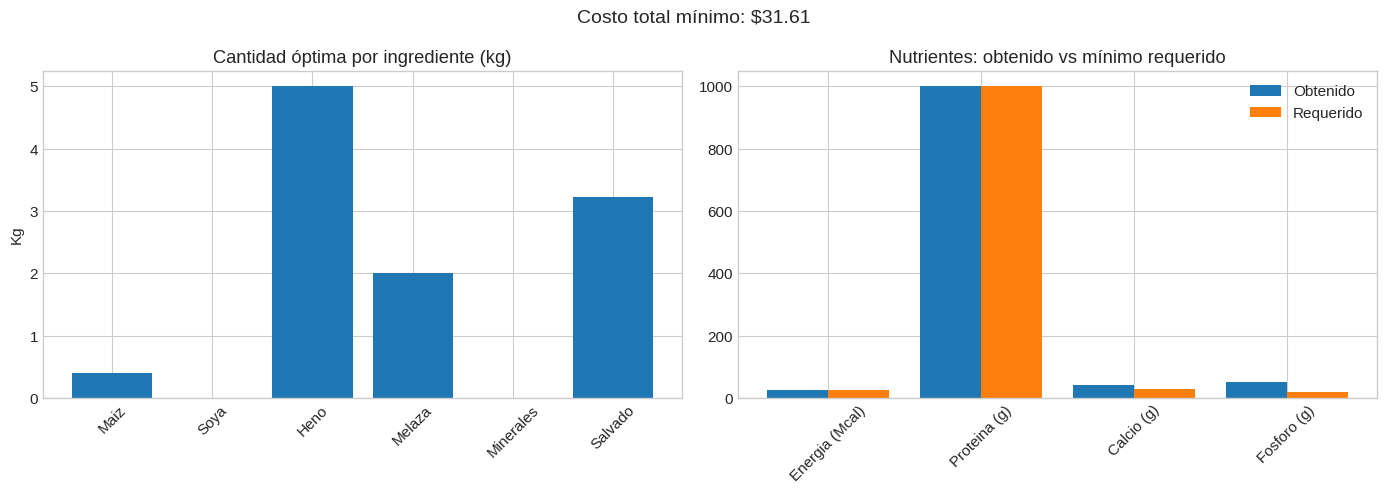

In [ ]:
# === EJECUTAR Y VISUALIZAR PROBLEMA 1 ===

def plot_p1(x_opt, costo_opt):
    """Visualiza la solucion del problema de nutricion.

    Debe mostrar:
    - Panel 1: Barras con kg de cada ingrediente
    - Panel 2: Barras comparando nutrientes obtenidos vs requeridos
    """

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # =========================
    # Panel 1: kg por ingrediente
    # =========================
    axes[0].bar(nombres_p1, x_opt)
    axes[0].set_title("Cantidad óptima por ingrediente (kg)")
    axes[0].set_ylabel("Kg")
    axes[0].tick_params(axis="x", rotation=45)

    # =========================
    # Panel 2: nutrientes vs requeridos
    # =========================
    nutrientes_tot = nutrientes_p1 @ x_opt
    x_pos = np.arange(len(nombres_nutrientes_p1))

    axes[1].bar(x_pos - 0.2, nutrientes_tot, width=0.4, label="Obtenido")
    axes[1].bar(x_pos + 0.2, req_min_p1, width=0.4, label="Requerido")

    axes[1].set_xticks(x_pos)
    axes[1].set_xticklabels(nombres_nutrientes_p1, rotation=45)
    axes[1].set_title("Nutrientes: obtenido vs mínimo requerido")
    axes[1].legend()

    plt.suptitle(f"Costo total mínimo: ${costo_opt:.2f}", fontsize=14)
    plt.tight_layout()
    plt.show()


# Resolver y visualizar
x_opt_p1, costo_opt_p1 = resolver_p1()
info_p1 = verificar_p1(x_opt_p1)

print(f"Solucion P1:")
for nombre, kg in zip(nombres_p1, x_opt_p1):
    print(f"  {nombre}: {kg:.3f} kg")
print(f"Costo total: ${costo_opt_p1:.2f}")
print(f"Intake total: {info_p1['intake_total']:.2f} kg")
print(f"Factible: {info_p1['factible']}")

plot_p1(x_opt_p1, costo_opt_p1)

---
## Problema 2: Portafolio de inversion (4 puntos)

Un inversionista tiene capital para distribuir entre 5 activos financieros. Cada activo tiene un **rendimiento esperado** y una **covarianza** conocida con los demas activos (ver datos).

El objetivo es **minimizar el riesgo** del portafolio (medido como la varianza del rendimiento), sujeto a:
- El rendimiento esperado del portafolio debe ser **al menos 8%**
- Todo el capital debe invertirse (las proporciones suman 1)
- No se permiten ventas en corto (todas las proporciones >= 0)
- Ningun activo puede representar mas del **40%** del portafolio

### 2.1 Formulacion matematica

<!-- ESCRIBE TU FORMULACION AQUI -->

**Variables de decision:**
Sea:

$$
w_i \ge 0, \quad i=1,\dots,5
$$

donde $w_i$ es la proporción del capital invertida en el activo $i$.


**Función objetivo**

Minimizar la varianza del portafolio:

$$
\min \; w^T \Sigma w
$$

donde:

- $w$ es el vector de proporciones
- $\Sigma$ es la matriz de covarianzas


**Restricciones**

Rendimiento mínimo:

$$
\sum_{i=1}^{5} \mu_i w_i \ge 0.08
$$

Todo el capital invertido:

$$
\sum_{i=1}^{5} w_i = 1
$$

No ventas en corto:

$$
w_i \ge 0
$$

Límite máximo por activo:

$$
w_i \le 0.40
$$

### 2.2 Eleccion de optimizador

<!-- ESCRIBE TU RESPUESTA AQUI -->

**Optimizador elegido:**
`scipy.optimize.minimize` (método SLSQP)
**Justificacion (2-3 oraciones):**
La función objetivo es cuadrática ($w^T \Sigma w$) y las restricciones son lineales (igualdad e inecuaciones). Esto corresponde a un problema de *optimización cuadrática con restricciones*.  

In [ ]:
# === DATOS PROBLEMA 2 (NO MODIFICAR) ===
activos_p2 = ["Bonos gob.", "Acciones tech", "Bienes raices", "Materias primas", "Mercados emergentes"]
rendimientos_p2 = np.array([0.03, 0.14, 0.08, 0.11, 0.16])

cov_p2 = np.array([
    [0.0004, 0.0002, 0.0001, 0.0000, 0.0003],
    [0.0002, 0.0100, 0.0030, 0.0050, 0.0080],
    [0.0001, 0.0030, 0.0025, 0.0015, 0.0020],
    [0.0000, 0.0050, 0.0015, 0.0064, 0.0040],
    [0.0003, 0.0080, 0.0020, 0.0040, 0.0144],
])

retorno_minimo_p2 = 0.08
max_por_activo_p2 = 0.40

In [ ]:
# === IMPLEMENTACION PROBLEMA 2 ===

def objetivo_p2(w):
    return w.T @ cov_p2 @ w


def verificar_p2(w):

    rendimiento = rendimientos_p2 @ w
    varianza = w.T @ cov_p2 @ w
    suma_pesos = w.sum()

    cumple_rend = rendimiento >= retorno_minimo_p2
    cumple_suma = np.isclose(suma_pesos, 1)
    cumple_no_neg = np.all(w >= 0)
    cumple_max = np.all(w <= max_por_activo_p2)

    factible = cumple_rend and cumple_suma and cumple_no_neg and cumple_max

    return {
        "factible": factible,
        "rendimiento": rendimiento,
        "varianza": varianza,
        "suma_pesos": suma_pesos
    }


def resolver_p2():

    # Punto inicial
    w0 = np.ones(5) / 5

    # Restricciones
    constraints = [
        {"type": "eq", "fun": lambda w: np.sum(w) - 1},
        {"type": "ineq", "fun": lambda w: rendimientos_p2 @ w - retorno_minimo_p2}
    ]

    bounds = [(0, max_por_activo_p2) for _ in range(5)]

    result = minimize(
        objetivo_p2,
        w0,
        method="SLSQP",
        bounds=bounds,
        constraints=constraints
    )

    return result.x, result.fun

Solucion P2:
  Bonos gob.: 35.7%
  Acciones tech: 9.9%
  Bienes raices: 27.4%
  Materias primas: 19.4%
  Mercados emergentes: 7.6%
Rendimiento esperado: 8.00%
Varianza: 0.001548
Desv. estandar: 3.93%
Factible: True


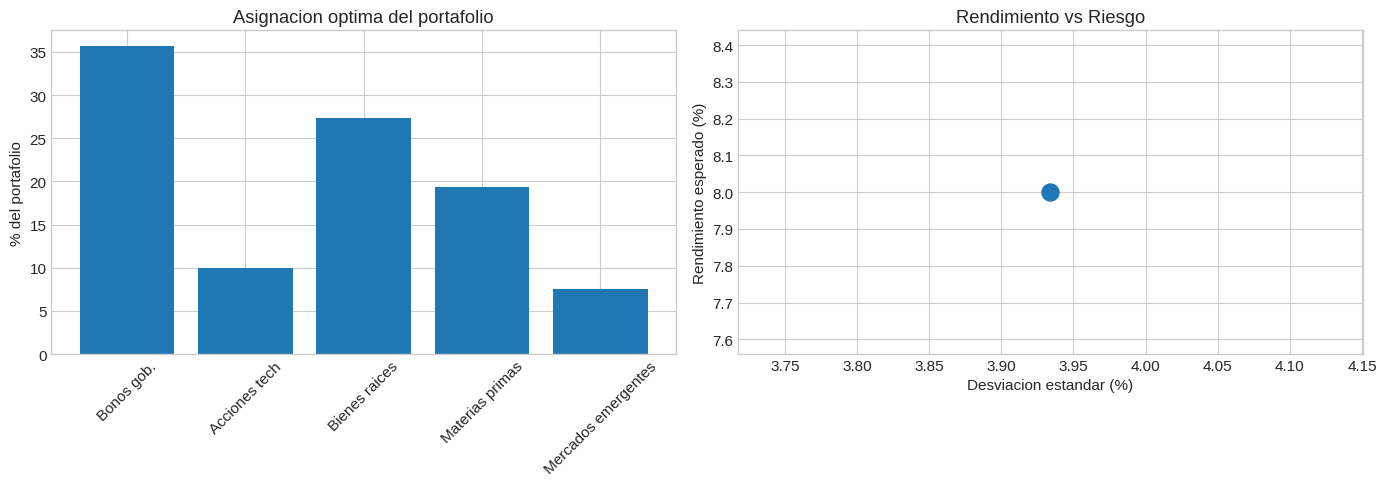

In [ ]:
# === EJECUTAR Y VISUALIZAR PROBLEMA 2 ===

def plot_p2(w_opt, varianza_opt):
    """Visualiza la solucion del portafolio.

    Debe mostrar:
    - Panel 1: Barras con la asignacion del portafolio (% por activo)
    - Panel 2: Rendimiento vs riesgo del portafolio optimo
    """
    rendimiento = rendimientos_p2 @ w_opt
    riesgo = np.sqrt(varianza_opt)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Panel 1
    axes[0].bar(activos_p2, w_opt * 100)
    axes[0].set_ylabel("% del portafolio")
    axes[0].set_title("Asignacion optima del portafolio")
    axes[0].tick_params(axis='x', rotation=45)

    # Panel 2
    axes[1].scatter(riesgo * 100, rendimiento * 100, s=150)
    axes[1].set_xlabel("Desviacion estandar (%)")
    axes[1].set_ylabel("Rendimiento esperado (%)")
    axes[1].set_title("Rendimiento vs Riesgo")

    plt.tight_layout()
    plt.show()


w_opt_p2, var_opt_p2 = resolver_p2()
info_p2 = verificar_p2(w_opt_p2)

print(f"Solucion P2:")
for activo, w in zip(activos_p2, w_opt_p2):
    print(f"  {activo}: {w*100:.1f}%")

print(f"Rendimiento esperado: {info_p2['rendimiento']*100:.2f}%")
print(f"Varianza: {var_opt_p2:.6f}")
print(f"Desv. estandar: {np.sqrt(var_opt_p2)*100:.2f}%")
print(f"Factible: {info_p2['factible']}")

plot_p2(w_opt_p2, var_opt_p2)

---
## Problema 3: Cobertura con antenas (4 puntos)

Una empresa de telecomunicaciones necesita dar cobertura de senal en **10 zonas** de una ciudad. Existen **7 ubicaciones** posibles para instalar torres de transmision. Cada torre tiene un costo de construccion y cubre un conjunto especifico de zonas (ver tabla).

El objetivo es **seleccionar que torres construir** para cubrir **todas las zonas** al **minimo costo** total. Cada torre se construye completamente o no se construye (decision binaria).

| Torre | Costo (miles \$) | Zonas que cubre |
|:-----:|:----------------:|:---------------:|
| T1    | 50               | 1, 2, 3         |
| T2    | 80               | 2, 3, 4, 5      |
| T3    | 60               | 4, 5, 6         |
| T4    | 70               | 5, 6, 7, 8      |
| T5    | 90               | 7, 8, 9, 10     |
| T6    | 40               | 1, 9, 10        |
| T7    | 75               | 3, 6, 7         |

### 3.1 Formulación matemática

**Variables de decisión:**

Sea:

$$
y_i =
\begin{cases}
1 & \text{si se construye la torre } i \\
0 & \text{si no se construye}
\end{cases}
\quad i=1,\dots,7
$$

**Función objetivo:**

Minimizar el costo total de construcción:

$$
\min \sum_{i=1}^{7} c_i y_i
$$

donde $c_i$ es el costo de la torre $i$.

**Restricciones:**

Cada zona $j$ debe estar cubierta por al menos una torre:

$$
\sum_{i=1}^{7} a_{ij} y_i \ge 1
\quad \forall j = 1,\dots,10
$$

donde:

- $a_{ij} = 1$ si la torre $i$ cubre la zona $j$
- $a_{ij} = 0$ en otro caso

Además:

$$
y_i \in \{0,1\}
\quad \forall i
$$

### 3.2 Elección de optimizador

**Optimizador elegido:**
`scipy.optimize.milp`

**Justificación:**

Este problema es binario, ya que las decisiones son 0 o 1 (construir o no cada torre). Además, la función objetivo es lineal y las restricciones también son lineales. Por lo tanto, es un problema de programación lineal entera (MILP), y el solver `milp` es adecuado para este tipo de problemas.

In [ ]:
# === DATOS PROBLEMA 3 (NO MODIFICAR) ===
n_torres_p3 = 7
n_zonas_p3 = 10
costos_torres_p3 = np.array([50, 80, 60, 70, 90, 40, 75])
nombres_torres_p3 = [f"T{i+1}" for i in range(n_torres_p3)]

# cobertura_p3[i, j] = 1 si torre i cubre zona j+1
cobertura_p3 = np.array([
    [1, 1, 1, 0, 0, 0, 0, 0, 0, 0],  # T1: zonas 1,2,3
    [0, 1, 1, 1, 1, 0, 0, 0, 0, 0],  # T2: zonas 2,3,4,5
    [0, 0, 0, 1, 1, 1, 0, 0, 0, 0],  # T3: zonas 4,5,6
    [0, 0, 0, 0, 1, 1, 1, 1, 0, 0],  # T4: zonas 5,6,7,8
    [0, 0, 0, 0, 0, 0, 1, 1, 1, 1],  # T5: zonas 7,8,9,10
    [1, 0, 0, 0, 0, 0, 0, 0, 1, 1],  # T6: zonas 1,9,10
    [0, 0, 1, 0, 0, 1, 1, 0, 0, 0],  # T7: zonas 3,6,7
])

In [ ]:
# === IMPLEMENTACION PROBLEMA 3 ===

def objetivo_p3(y):
    """Calcula el costo total de las torres seleccionadas.

    Args:
        y: np.array (7,) -- 1 si se construye la torre, 0 si no

    Returns:
        float -- costo total
    """
    return costos_torres_p3 @ y


def verificar_p3(y):
    """Verifica si la seleccion de torres cubre TODAS las zonas.

    Args:
        y: np.array (7,) -- seleccion de torres

    Returns:
        dict con:
            'factible': bool
            'zonas_cubiertas': list -- indices de zonas cubiertas
            'zonas_sin_cubrir': list -- indices de zonas sin cobertura
    """
    cobertura_total = cobertura_p3.T @ y

    zonas_cubiertas = [i+1 for i in range(n_zonas_p3) if cobertura_total[i] >= 1]
    zonas_sin_cubrir = [i+1 for i in range(n_zonas_p3) if cobertura_total[i] < 1]

    factible = len(zonas_sin_cubrir) == 0

    return {
        'factible': factible,
        'zonas_cubiertas': zonas_cubiertas,
        'zonas_sin_cubrir': zonas_sin_cubrir
    }


def resolver_p3():
    """Resuelve el problema de cobertura con antenas.

    Returns:
        y_opt: np.array (7,) -- seleccion optima de torres
        costo_opt: float -- costo minimo
    """

    # Minimizar costos
    c = costos_torres_p3

    # Restricciones: cada zona debe estar cubierta
    # cobertura_p3.T @ y >= 1
    A = cobertura_p3.T
    lb = np.ones(n_zonas_p3)      # mínimo 1 por zona
    ub = np.full(n_zonas_p3, np.inf)

    constraints = LinearConstraint(A, lb=lb, ub=ub)

    # Variables binarias
    integrality = np.ones(n_torres_p3)

    bounds = Bounds(lb=np.zeros(n_torres_p3),
                    ub=np.ones(n_torres_p3))

    result = milp(c=c,
                  constraints=constraints,
                  integrality=integrality,
                  bounds=bounds)

    y_opt = result.x
    costo_opt = result.fun

    return y_opt, costo_opt

Solucion P3:
  T2: Construir (costo=$80k, cubre zonas [2, 3, 4, 5])
  T4: Construir (costo=$70k, cubre zonas [5, 6, 7, 8])
  T6: Construir (costo=$40k, cubre zonas [1, 9, 10])
Costo total: $190k
Factible: True
Zonas sin cubrir: []


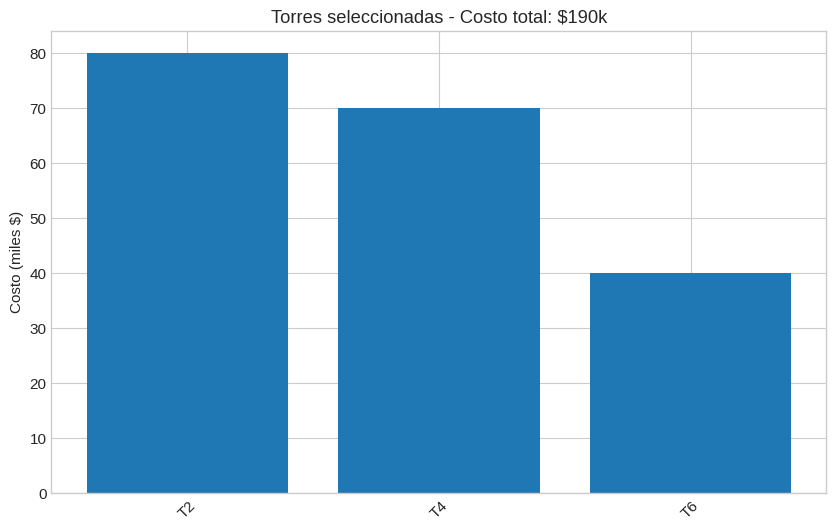

In [ ]:
# === EJECUTAR Y VISUALIZAR PROBLEMA 3 ===

def plot_p3(y_opt, costo_opt):
    """Visualiza la seleccion de torres y la cobertura."""

    fig, ax = plt.subplots(figsize=(10, 6))

    seleccion = [nombres_torres_p3[i] for i in range(n_torres_p3) if y_opt[i] > 0.5]
    costos = [costos_torres_p3[i] for i in range(n_torres_p3) if y_opt[i] > 0.5]

    ax.bar(seleccion, costos)
    ax.set_ylabel("Costo (miles $)")
    ax.set_title(f"Torres seleccionadas - Costo total: ${costo_opt:.0f}k")

    plt.xticks(rotation=45)
    plt.show()


# Resolver y visualizar
y_opt_p3, costo_opt_p3 = resolver_p3()
info_p3 = verificar_p3(y_opt_p3)

print(f"Solucion P3:")
for i, (nombre, sel) in enumerate(zip(nombres_torres_p3, y_opt_p3)):
    if sel > 0.5:
        zonas = [j+1 for j in range(n_zonas_p3) if cobertura_p3[i, j] == 1]
        print(f"  {nombre}: Construir (costo=${costos_torres_p3[i]:.0f}k, cubre zonas {zonas})")

print(f"Costo total: ${costo_opt_p3:.0f}k")
print(f"Factible: {info_p3['factible']}")
print(f"Zonas sin cubrir: {info_p3['zonas_sin_cubrir']}")

plot_p3(y_opt_p3, costo_opt_p3)

---
## Problema 4: Calibracion de sensor (4 puntos)

Un ingeniero necesita calibrar un sensor cuya respuesta sigue el modelo:

$$y(t) = a \cdot \sin(b \cdot t + c) + d \cdot e^{-0.1 \cdot t}$$

donde $a, b, c, d$ son parametros desconocidos y $t$ es la posicion del sensor.

Se tienen **20 mediciones** del sensor en posiciones conocidas (ver datos). El objetivo es encontrar los parametros $a, b, c, d$ que **minimicen el error** entre las predicciones del modelo y las mediciones observadas.

**Nota:** El paisaje de error tiene **multiples minimos locales** debido a los terminos trigonometricos.

**Cotas de los parametros:** $a \in [0, 5]$, $b \in [0, 10]$, $c \in [0, 2\pi]$, $d \in [-3, 3]$

### 4.1 Formulación matemática

**Variables de decisión:**

$$
\theta = (a,b,c,d)
$$

donde:

$$
a \in [0,5], \quad
b \in [0,10], \quad
c \in [0,2\pi], \quad
d \in [-3,3]
$$

**Modelo del sensor:**

$$
y(t;\theta) = a \sin(bt + c) + d e^{-0.1t}
$$

**Función objetivo:**

Minimizar el error cuadrático total:

$$
\min_{a,b,c,d}
\sum_{i=1}^{20}
\left(
y_{obs,i} - y(t_i; \theta)
\right)^2
$$

**Restricciones:**

$$
(a,b,c,d) \in [0,5] \times [0,10] \times [0,2\pi] \times [-3,3]
$$

### 4.2 Elección de optimizador

**Optimizador elegido:**  
`scipy.optimize.differential_evolution`

**Justificación:**

La función objetivo es no convexa y tiene múltiples mínimos locales debido al término sinusoidal. Por ello, un método basado en gradiente podría quedar atrapado en un mínimo local. `differential_evolution` es un algoritmo global poblacional que explora el espacio completo de parámetros y es más adecuado para este tipo de problemas multimodales.

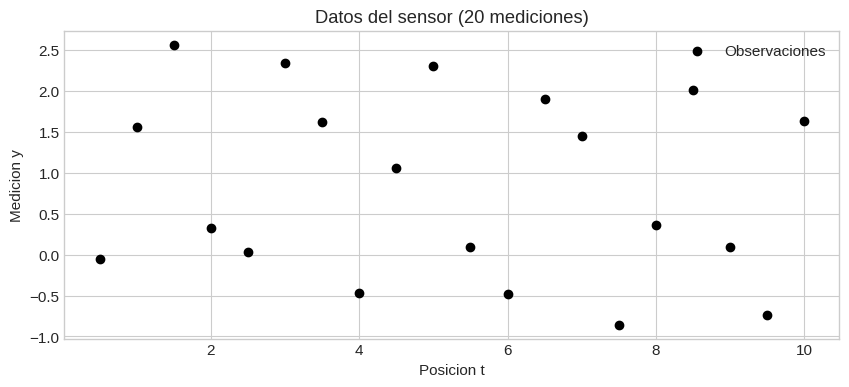

In [ ]:
# === DATOS PROBLEMA 4 (NO MODIFICAR) ===

def modelo_sensor(t, params):
    """Modelo del sensor: y = a*sin(b*t + c) + d*exp(-0.1*t)

    Args:
        t: np.array -- posiciones
        params: np.array (4,) -- [a, b, c, d]

    Returns:
        np.array -- predicciones del modelo
    """
    a, b, c, d = params
    return a * np.sin(b * t + c) + d * np.exp(-0.1 * t)

# Posiciones de medicion
t_obs_p4 = np.linspace(0.5, 10.0, 20)

# Mediciones observadas (generadas con parametros ocultos + ruido)
_rng_p4 = np.random.default_rng(2026)
_params_ocultos = _rng_p4.uniform([1, 1, 0, 0.5], [4, 5, 2*np.pi, 3])
y_obs_p4 = modelo_sensor(t_obs_p4, _params_ocultos) + _rng_p4.normal(0, 0.2, 20)
del _rng_p4, _params_ocultos

bounds_p4 = [(0, 5), (0, 10), (0, 2*np.pi), (-3, 3)]

# Visualizar los datos
plt.figure(figsize=(10, 4))
plt.scatter(t_obs_p4, y_obs_p4, color="black", zorder=5, label="Observaciones")
plt.xlabel("Posicion t"); plt.ylabel("Medicion y")
plt.title("Datos del sensor (20 mediciones)")
plt.legend(); plt.show()

In [ ]:
# === IMPLEMENTACION PROBLEMA 4 ===

def objetivo_p4(params):
    """Calcula el error cuadratico total entre modelo y observaciones."""
    y_pred = modelo_sensor(t_obs_p4, params)
    error = np.sum((y_obs_p4 - y_pred)**2)
    return error


def resolver_p4():
    """Resuelve el problema de calibracion."""

    result = differential_evolution(
        objetivo_p4,
        bounds=bounds_p4,
        seed=42
    )

    params_opt = result.x
    error_opt = result.fun

    return params_opt, error_opt

Solucion P4:
a = 1.5090
b = 3.5530
c = 2.9058
d = 1.4254
Error: 0.088386


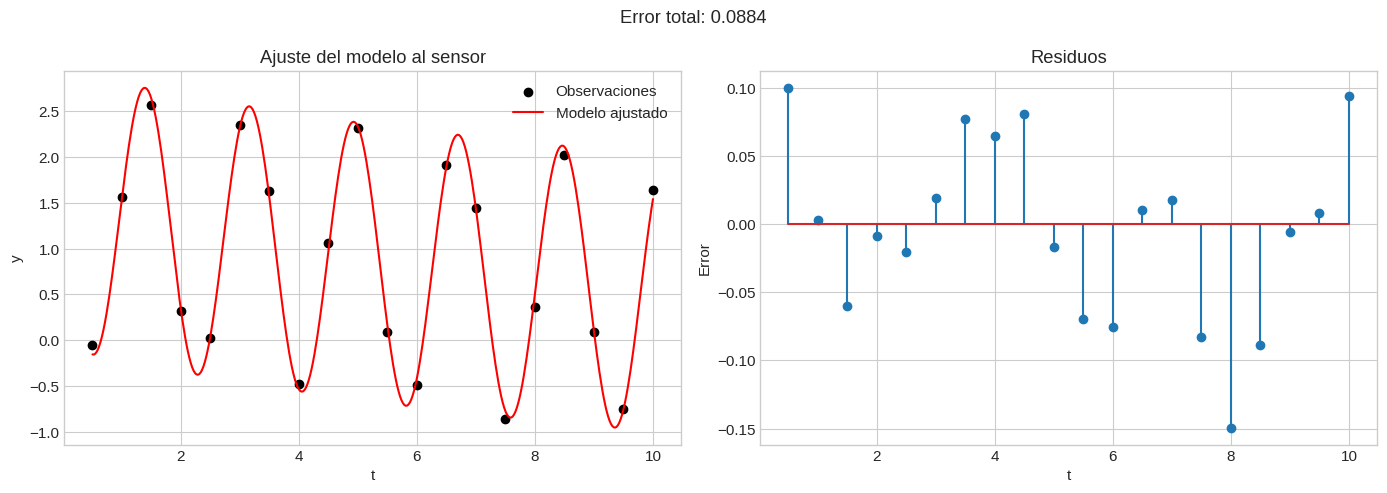

In [ ]:
# === EJECUTAR Y VISUALIZAR PROBLEMA 4 ===

def plot_p4(params_opt, error_opt):

    t_fino = np.linspace(t_obs_p4.min(), t_obs_p4.max(), 400)
    y_modelo = modelo_sensor(t_fino, params_opt)
    y_pred_obs = modelo_sensor(t_obs_p4, params_opt)
    residuos = y_obs_p4 - y_pred_obs

    fig, axes = plt.subplots(1, 2, figsize=(14,5))

    # Panel 1: ajuste
    axes[0].scatter(t_obs_p4, y_obs_p4, color="black", label="Observaciones")
    axes[0].plot(t_fino, y_modelo, color="red", label="Modelo ajustado")
    axes[0].set_title("Ajuste del modelo al sensor")
    axes[0].set_xlabel("t")
    axes[0].set_ylabel("y")
    axes[0].legend()

    # Panel 2: residuos
    axes[1].stem(t_obs_p4, residuos)
    axes[1].set_title("Residuos")
    axes[1].set_xlabel("t")
    axes[1].set_ylabel("Error")

    plt.suptitle(f"Error total: {error_opt:.4f}")
    plt.tight_layout()
    plt.show()


# Resolver y visualizar
params_opt_p4, error_opt_p4 = resolver_p4()

print("Solucion P4:")
print(f"a = {params_opt_p4[0]:.4f}")
print(f"b = {params_opt_p4[1]:.4f}")
print(f"c = {params_opt_p4[2]:.4f}")
print(f"d = {params_opt_p4[3]:.4f}")
print(f"Error: {error_opt_p4:.6f}")

plot_p4(params_opt_p4, error_opt_p4)

---
## Problema 5: Red de distribucion (4 puntos)

Una empresa de logistica considera abrir centros de distribucion (CDs) en **4 ciudades** posibles para atender a **6 clientes**. Cada CD tiene un **costo fijo** de apertura, una **capacidad maxima**, y un **costo de envio por unidad** a cada cliente. Cada cliente tiene una **demanda** que debe ser satisfecha completamente.

La empresa debe decidir:
1. **Que CDs abrir** (decision binaria: abrir o no)
2. **Cuantas unidades enviar** de cada CD abierto a cada cliente (decision continua)

El objetivo es **minimizar el costo total** (costos fijos de apertura + costos de envio).

| CD | Ciudad      | Costo fijo (miles \$) | Capacidad |
|:--:|:-----------:|:--------------------:|:---------:|
| 1  | Guadalajara | 800                  | 500       |
| 2  | Monterrey   | 700                  | 400       |
| 3  | CDMX        | 1000                 | 600       |
| 4  | Merida      | 600                  | 350       |

| Cliente | C1  | C2 | C3  | C4  | C5  | C6  |
|:-------:|:---:|:--:|:---:|:---:|:---:|:---:|
| Demanda | 120 | 80 | 200 | 150 | 100 | 180 |

**Costos de envio** (\$ por unidad):

|      | C1 | C2 | C3 | C4 | C5 | C6 |
|:----:|:--:|:--:|:--:|:--:|:--:|:--:|
| GDL  | 4  | 8  | 5  | 9  | 7  | 6  |
| MTY  | 7  | 3  | 6  | 8  | 4  | 9  |
| CDMX | 5  | 6  | 3  | 4  | 8  | 5  |
| MER  | 9  | 7  | 8  | 3  | 6  | 4  |

### 5.1 Formulación matemática

**Variables de decisión:**

- $y_i \in \{0,1\}$: 1 si se abre el CD $i$, 0 si no.
- $x_{ij} \ge 0$: unidades enviadas del CD $i$ al cliente $j$.

**Función objetivo:**

Minimizar costo total:

$$
\min \sum_{i=1}^{4} F_i y_i +
\sum_{i=1}^{4} \sum_{j=1}^{6} c_{ij} x_{ij}
$$

donde:
- $F_i$ es el costo fijo del CD $i$
- $c_{ij}$ es el costo de envío

**Restricciones:**

1. Satisfacción de demanda:

$$
\sum_{i=1}^{4} x_{ij} = D_j
\quad \forall j
$$

2. Capacidad:

$$
\sum_{j=1}^{6} x_{ij} \le Cap_i \, y_i
\quad \forall i
$$

3. Dominio:

$$
y_i \in \{0,1\}, \quad x_{ij} \ge 0
$$

### 5.2 Elección de optimizador

**Optimizador elegido:** `scipy.optimize.milp`

**Justificación:**

El problema es lineal en la función objetivo y restricciones, pero contiene variables binarias (apertura de CDs) y continuas (flujos). Esto lo convierte en un problema de programación lineal entera mixta (MILP), por lo que `milp` es el solver adecuado.

In [ ]:
# === DATOS PROBLEMA 5 (NO MODIFICAR) ===
ciudades_p5 = ["Guadalajara", "Monterrey", "CDMX", "Merida"]
n_cds_p5 = 4
n_clientes_p5 = 6

costos_fijos_p5 = np.array([800, 700, 1000, 600])    # miles $
capacidades_p5 = np.array([500, 400, 600, 350])
demandas_p5 = np.array([120, 80, 200, 150, 100, 180])

# costos_envio_p5[i, j] = costo de enviar 1 unidad de CD i a cliente j
costos_envio_p5 = np.array([
    [4, 8, 5, 9, 7, 6],   # Guadalajara
    [7, 3, 6, 8, 4, 9],   # Monterrey
    [5, 6, 3, 4, 8, 5],   # CDMX
    [9, 7, 8, 3, 6, 4],   # Merida
])

In [ ]:
# === IMPLEMENTACION PROBLEMA 5 ===

def objetivo_p5(y, X):
    return costos_fijos_p5 @ y + np.sum(costos_envio_p5 * X)


def verificar_p5(y, X):

    demanda_cumplida = X.sum(axis=0)
    capacidad_usada = X.sum(axis=1)

    cumple_demanda = np.allclose(demanda_cumplida, demandas_p5)
    cumple_capacidad = np.all(capacidad_usada <= capacidades_p5 * y + 1e-6)

    factible = cumple_demanda and cumple_capacidad

    return {
        'factible': factible,
        'demanda_cumplida': demanda_cumplida,
        'capacidad_usada': capacidad_usada
    }


def resolver_p5():

    n_y = n_cds_p5
    n_x = n_cds_p5 * n_clientes_p5
    n_vars = n_y + n_x

    # Vector de costos
    c = np.zeros(n_vars)
    c[:n_y] = costos_fijos_p5
    c[n_y:] = costos_envio_p5.flatten()

    # === Restricciones ===

    A = []
    lb = []
    ub = []

    # 1️⃣ Restricciones de demanda
    for j in range(n_clientes_p5):
        row = np.zeros(n_vars)
        for i in range(n_cds_p5):
            row[n_y + i*n_clientes_p5 + j] = 1
        A.append(row)
        lb.append(demandas_p5[j])
        ub.append(demandas_p5[j])

    # 2️⃣ Restricciones de capacidad
    for i in range(n_cds_p5):
        row = np.zeros(n_vars)
        for j in range(n_clientes_p5):
            row[n_y + i*n_clientes_p5 + j] = 1
        row[i] = -capacidades_p5[i]
        A.append(row)
        lb.append(-np.inf)
        ub.append(0)

    A = np.array(A)
    lb = np.array(lb)
    ub = np.array(ub)

    constraints = LinearConstraint(A, lb, ub)

    # Integrality
    integrality = np.zeros(n_vars)
    integrality[:n_y] = 1  # solo y son binarias

    bounds = Bounds(
        lb=np.zeros(n_vars),
        ub=np.concatenate([np.ones(n_y), np.full(n_x, np.inf)])
    )

    result = milp(c=c,
                  constraints=constraints,
                  integrality=integrality,
                  bounds=bounds)

    sol = result.x

    y_opt = sol[:n_y]
    X_opt = sol[n_y:].reshape(n_cds_p5, n_clientes_p5)
    costo_opt = result.fun

    return y_opt, X_opt, costo_opt

Solucion P5:
CDMX ABIERTO (480/600)
Merida ABIERTO (350/350)
Costo total: $5130k
Factible: True


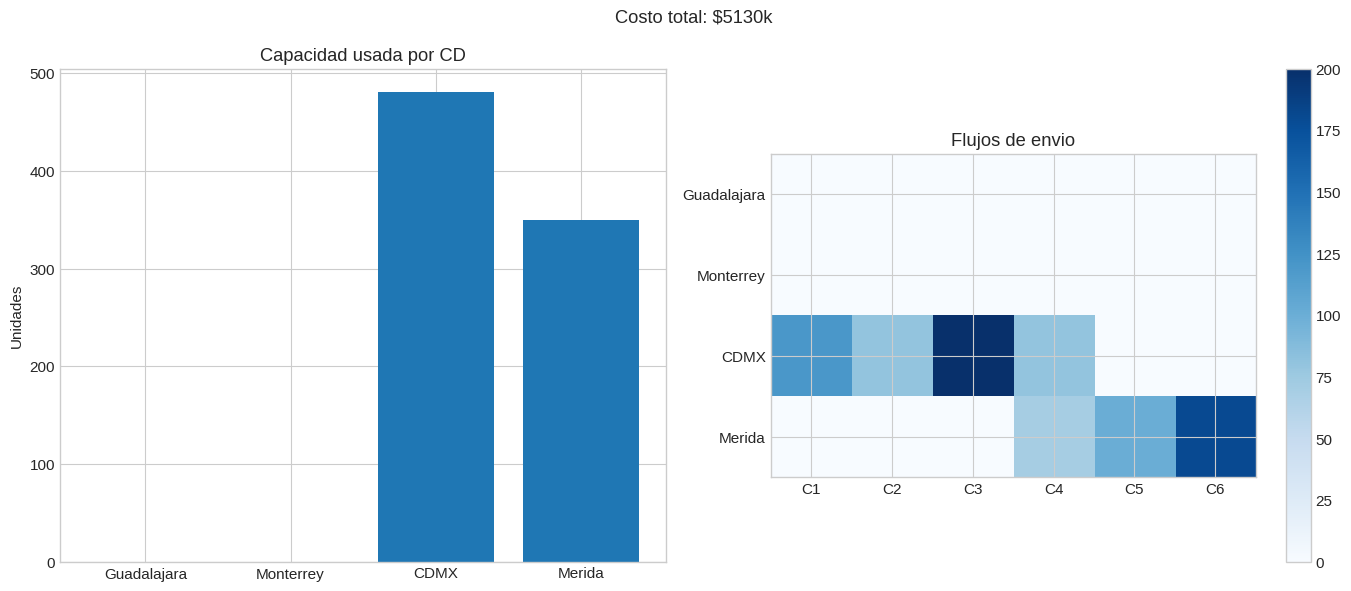

In [ ]:
# === EJECUTAR Y VISUALIZAR PROBLEMA 5 ===

def plot_p5(y_opt, X_opt, costo_opt):

    fig, axes = plt.subplots(1, 2, figsize=(14,6))

    # Panel 1: CDs abiertos
    abiertos = [ciudades_p5[i] for i in range(n_cds_p5) if y_opt[i] > 0.5]
    capacidad_usada = X_opt.sum(axis=1)

    axes[0].bar(ciudades_p5, capacidad_usada)
    axes[0].set_title("Capacidad usada por CD")
    axes[0].set_ylabel("Unidades")

    # Panel 2: matriz de envios
    im = axes[1].imshow(X_opt, cmap="Blues")
    axes[1].set_xticks(range(n_clientes_p5))
    axes[1].set_xticklabels([f"C{j+1}" for j in range(n_clientes_p5)])
    axes[1].set_yticks(range(n_cds_p5))
    axes[1].set_yticklabels(ciudades_p5)
    axes[1].set_title("Flujos de envio")

    plt.colorbar(im, ax=axes[1])
    plt.suptitle(f"Costo total: ${costo_opt:.0f}k")
    plt.tight_layout()
    plt.show()


# Ejecutar
y_opt_p5, X_opt_p5, costo_opt_p5 = resolver_p5()
info_p5 = verificar_p5(y_opt_p5, X_opt_p5)

print("Solucion P5:")
for i, ciudad in enumerate(ciudades_p5):
    if y_opt_p5[i] > 0.5:
        print(f"{ciudad} ABIERTO ({X_opt_p5[i].sum():.0f}/{capacidades_p5[i]})")

print(f"Costo total: ${costo_opt_p5:.0f}k")
print(f"Factible: {info_p5['factible']}")

plot_p5(y_opt_p5, X_opt_p5, costo_opt_p5)